# NYT Connections Puzzle Solver
## DATA 620 Final Project

Authors: Kevin Havis and Aaliyah John-Harry

## Introduction

The New York Times hosts several puzzle games on its website, but perhaps the most popular is Connections.

Connections is a word game where the player is given sixteen words and must group them into four categories of four words each based on hidden relationships or implicit patterns.

These relationships may be semantic, structural (prefixes/suffixes), or cultural references. The puzzle is intentionally designed to mislead players with plausible but incorrect groupings. In practice, players look for logical groups of four words, progressively eliminating words as they get the groupings correct.

Our goal is to develop a model that can automatically group the sixteen words into their correct categories using a combination of natural language processing (NLP) and network analysis techniques.

### Research Question
Can a combination of semantic embeddings and network-based clustering accurately identify the hidden groupings in NYT Connections puzzles, outperforming baseline methods such as random grouping and simple similarity measures?

### Hypothesis
We expect that combining word embeddings with network-based clustering will outperform both random grouping and simple cosine similarity, approaching human-level performance on historical puzzles.

### Potential Challenges/Concerns

- The primary challenge is the diversity of relationships between words.
    - Simple methods such as cosine similarity may capture semantic meaning but fail to detect structural or contextual patterns.
    - Additionally, the puzzle often intentionally misdirects the player by providing words that can be intuitively grouped but do not fit the predetermined category.
- Categories may rely on cultural knowledge not captured by NLP techniques.
    - Additionally, clustering evaluation is complex due to multiple plausible groupings. 

### Approach

We have several tools we can use to take on this problem.

#### Data

We will use historical NYT Connections puzzles and their solutions from a public GitHub dataset maintained by *Eyefyre* on [GitHub](https://github.com/Eyefyre/NYT-Connections-Answers).


#### Techniques

We must use a combination of techniques to address all potential "angles" of word classification.

- Word Embeddings: Vectorizing the words can give us some initial groupings of similar words by common language 
- Text Processing: Stemming and lemmatization will be used to identify structural relationships.
- Network analysis: Modeling the words as nodes and their connections as edges is a natural approach to this type of "neighbor" clustering

#### Evaluation

Model evaluation for clustering can be challenging; to measure our model's performance, we will compare against the following benchmarks.

- Random Association: Random grouping of words, measured by accuracy
- Simple Word Vector Embeddings: Groups based on semantic similarity.
- LLM Performance: Human-equivalent or better performance
- Human Benchmark: Comparison against known puzzle solutions.

Performance will be measured based on how accurately the model reproduces the correct groupings.

### Roles and Responsibilities

- Aaliyah John-Harry:
    - Text preprocessing
    - Feature engineering
    - Model development
- Kevin Havis:
    - Network construction
    - Graph analysis
    - Clustering methods
- Both:
    - Evaluation
    - Interpretation
    - Presentation

In [4]:
import os, sys

print(os.getcwd())
print(sys.path[:3])

/Users/aaliyahmjh/data_620/project4
['/Users/aaliyahmjh/data_620/project4', '/opt/anaconda3/lib/python312.zip', '/opt/anaconda3/lib/python3.12']


In [5]:
# Note - import will take a while as we load all the GloVe embeddings
from data import DataLoader
from embeddings import Embedder

[===-----------------------------------------------] 6.2% 23.4/376.1MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[===========---------------------------------------] 23.7% 89.3/376.1MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[===============-----------------------------------] 31.8% 119.6/376.1MB downloaded

...

[======================================------------] 76.9% 289.3/376.1MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[==============================================----] 92.9% 349.2/376.1MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[==================================================] 100.0% 376.1/376.1MB downloaded


In [6]:
loader = DataLoader()
df = loader.load()

In [7]:
embedder = Embedder(words=[])

Words: ['club', 'diamond', 'heart', 'spade', 'sandwich', 'knuckle', 'open', 'ham', 'ace', 'king', 'queen', 'jack', 'flush', 'straight', 'full', 'royal']

Loading GloVe embeddings for 16 words...
Embeddings shape: (16, 300)

Computing cosine similarity matrix...
Similarity matrix:
[[ 0.9999998   0.21613275  0.2309362  -0.01247939  0.097752   -0.02392899
   0.30434898  0.31011045  0.21845786  0.20379128  0.23206723  0.25078437
  -0.00869696  0.25547075  0.28198332  0.3158537 ]
 [ 0.21613275  1.0000006   0.21192668  0.11824514  0.08566822  0.03675086
   0.14687744  0.07350971  0.15594405  0.19179617  0.23214369  0.20263605
   0.02807982  0.12039277  0.13323586  0.15018055]
 [ 0.2309362   0.21192668  1.0000005  -0.01901735  0.07016855  0.02350878
   0.24221092  0.0531497   0.12194828  0.21747702  0.22896445  0.24929759
   0.10739119  0.17352656  0.20537998  0.1873827 ]
 [-0.01247939  0.11824514 -0.01901735  1.0000004   0.09033093  0.13715658
   0.04290726  0.08563322  0.03617079 -0.0032990

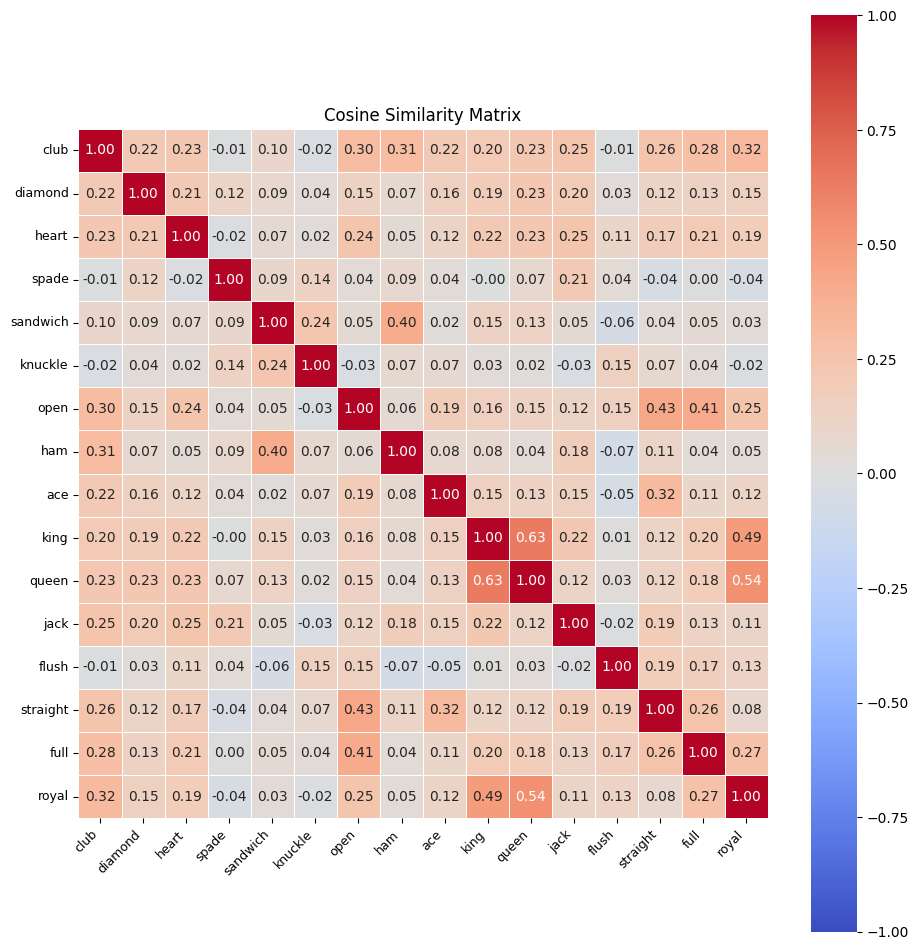

In [8]:
embedder.demo()